Regresja liniowa to algorytm uczenia nadzorowanego, który modeluje zależność między
zmiennymi niezależnymi (cechami) a zmienną zależną (targetem) jako funkcję liniową.
Model zakłada, że target można przewidzieć jako ważoną sumę cech plus wyraz wolny.

Regresja liniowa to "Hello World" Machine Learning. Mimo swojej prostoty, jest niezwykle
użyteczna:
- Łatwa do interpretacji (każdy współczynnik ma jasne znaczenie)
- Szybka do trenowania (rozwiązanie analityczne)
- Dobrze działa dla wielu problemów biznesowych
- Stanowi baseline dla bardziej złożonych modeli

Równanie regresji liniowej:
Dla jednej cechy (prosta regresja):
y = w₀ + w₁x

Dla wielu cech (regresja wieloraka):Definition
y = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ

gdzie:
- y - przewidywana wartość (target)
- x₁, x₂, ..., xₙ - cechy (features)
- w₀ - wyraz wolny (intercept, bias)
- w₁, w₂, ..., wₙ - współczynniki (wagi, weights)

szum np.random.normal(loc, scale, size), z rozkładu normalnego (czyli z rozkładu Gaussa)
loc – to średnia wartość szumu (chcemy, żeby wynosiła 0, czyli żeby szum raz był na plusie, a raz na minusie).
scale – to odchylenie standardowe (jak bardzo punkty mają "rozjeżdżać się" od naszej idealnej prostej – np. 2 lub 3).
size – ile tych liczb chcemy wylosować (u nas X.shape, czyli 50 sztuk).

Zadanie 1 – Prosta regresja liniowa od zera
Zaimplementuj prostą regresję liniową (y = wx + b) bez użycia sklearn.

Dataset: Wygeneruj 50 punktów według wzoru y = 3x + 2 + szum

Wymagania:
Oblicz współczynniki metodą najmniejszych kwadratów (OLS)
Porównaj wyniki ze sklearn LinearRegression
Narysuj wykres z danymi i linią regresji

Oczekiwany rezultat:
Wyuczone w ≈ 3, b ≈ 2
Wykres regresji

=== Dane ===
Liczba obserwacji: 50
X: zakres [0.0, 10.0]
y: zakres[2.2, 33.9]

=== Wyuczone parametry ===
Wyraz wolny (intercept): w₀ = 2.1933 (prawdziwy: 5)
Nachylenie (slope): w₁ = 2.8260 (prawdziwy: 2)


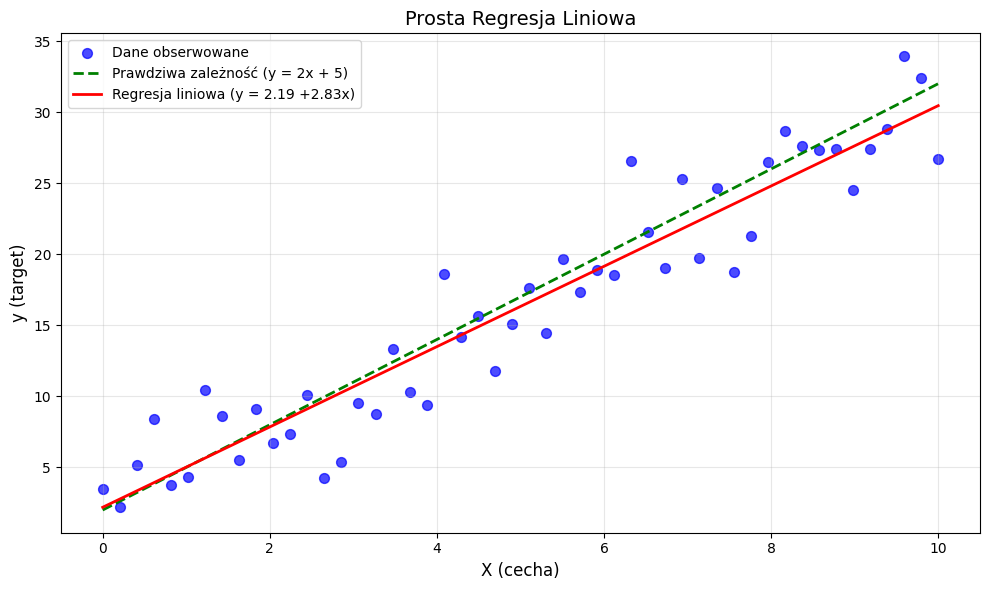

In [ ]:
import numpy as np
import matplotlib.pylab as plt

# Generowanie prostych danych
np.random.seed(42)
X = np.linspace(0, 10, 50) # 50 punktów od 0 do 10
y_true = 3 * X + 2 # Prawdziwa zależność: y = 3x + 2
noise = np.random.normal(0, 3, size=X.shape) # SZUM: średnia=0, rozrzut (odchylenie)=3, ilość=50, z rozkładu normalnego (czyli z rozkładu Gaussa)
y = y_true + noise # Obserwowane dane z zakłuceniami

print("=== Dane ===")
print(f"Liczba obserwacji: {len(X)}")
print(f"X: zakres [{X.min():.1f}, {X.max():.1f}]")
print(f"y: zakres[{y.min():.1f}, {y.max():.1f}]")

# ========================================================
# MATEMATYKA OD ZERA: Metoda Najmniejszych Kwadratów (OLS)
# ========================================================
# Rozwiązanie analityczne (Ordinary Least Squares) (y = wx + b)
# (w) w₁ = Σ(x - x̄ )(y - ȳ) / Σ(x - x̄ )²
# (b)w₀ = ȳ - w₁x

# 1. Liczymy średnie (czyli x z kreską oraz y z kreską)
X_mean = np.mean(X)
y_mean = np.mean(y)

# Obliczenie współczynnika nachylenia (slope)
# 2. Licznik wzoru na w1: suma iloczynów odchyleń
numerator = np.sum((X - X_mean) * (y - y_mean))

# 3. Mianownik wzoru na w1: suma kwadratów odchyleń x
denominator = np.sum((X - X_mean) ** 2)

w1 = numerator / denominator

# Obliczenie wyrazu wolnego (intercept)
w0 = y_mean - w1 * X_mean

print(f"\n=== Wyuczone parametry ===")
print(f"Wyraz wolny (intercept): w₀ = {w0.item():.4f} (prawdziwy: 5)")
print(f"Nachylenie (slope): w₁ = {w1.item():.4f} (prawdziwy: 2)")

# Predykcja
y_pred = w0 + w1 * X

# Wizualizacja
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Dane obserwowane', color='blue', s=50)
plt.plot(X, y_true, 'g--', label='Prawdziwa zależność (y = 2x + 5)', linewidth=2)
plt.plot(X, y_pred, 'r-', label=f'Regresja liniowa (y = {w0:.2f} +{w1:.2f}x)', linewidth=2)
plt.xlabel('X (cecha)', fontsize=12)
plt.ylabel('y (target)', fontsize=12)
plt.title('Prosta Regresja Liniowa', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Zadanie 2 – Interpretacja współczynników
Dataset: Stwórz syntetyczne dane sprzedażowe:
Wymagania:

- cena (50-200)
- reklama (100-5000)
- sezon (1-4)
- sprzedaż = -2cena + 0.5reklama + 100*sezon + 5000 + szum

Wymagania:
- Wytrenuj model regresji
- Zinterpretuj każdy współczynnik
- Odpowiedz: o ile wzrośnie sprzedaż, jeśli zwiększymy budżet reklamowy o 1000?

Oczekiwany rezultat:
- Interpretacja wszystkich współczynników
- Odpowiedź na pytanie biznesowe

In [27]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Blokada losowości:
np.random.seed(42)
n = 1000

# 2. Generowanie cech zgodnie z treścią zadania:
price = np.random.uniform(50, 200, n) # Cena (50-200)
advertising_budget = np.random.uniform(100, 5000, n) # reklama (100-5000)
season = np.random.normal(1, 5, n) # sezon (1-4) jako liczby 1, 2, 3, 4

# 3. Szum z rozkładu normalnego
noise = np.random.normal(0, 50, n)

# 4. Target według dokładnego wzoru z zadania
# sprzedaż = -2*cena + 0.5*reklama + 100*sezon + 5000 + szum
sales = -2 * price + 0.5 * advertising_budget + 100 * season + 5000 + noise

# 5. Tworzenie DataFrame i przygotowanie do sklearn
df = pd.DataFrame({
    'cena': price,
    'reklama': advertising_budget,
    'sezon': season,
    'sprzedaz': sales
})

X = df[['cena', 'reklama', 'sezon']]
y = df['sprzedaz']

# ========================================================
# KROK 1: Model na oryginalnych danych (Interpretacja Biznesowa)
# ========================================================
model_raw = LinearRegression()
model_raw.fit(X, y)

print("=== MODEL NA ORYGINALNYCH DANYCH ===")
print(f"Intercept (Wyraz wolny w₀): {model_raw.intercept_:.2f}")

interpretations = {
    'cena': f"{model_raw.coef_[0]:.2f} → Każdy wzrost ceny o 1 zł ZMNIEJSZA sprzedaż o {abs(model_raw.coef_[0]):.2f} szt.",
    'reklama': f"{model_raw.coef_[1]:.2f} → Każda dodatkowa 1 zł na reklamę ZWIĘKSZA sprzedaż o {model_raw.coef_[1]:.2f} szt.",
    'sezon': f"{model_raw.coef_[2]:.2f} → Zmiana sezonu o 1 stopień w górę ZWIĘKSZA sprzedaż o {model_raw.coef_[2]:.2f} szt."
}

for name, interp in interpretations.items():
    print(f" {name}: {interp}")

# Odpowiedź na pytanie biznesowe
odpowiedz_biznesowa = 1000 * model_raw.coef_[1]
print(f"\nODPOWIEDŹ BIZNESOWA: Jeśli zwiększymy budżet reklamowy o 1000 zł, sprzedaż wzrośnie o {odpowiedz_biznesowa:.2f} szt.\n")

# ========================================================
# KROK 2: Model na danych standaryzowanych (Porównanie Ważności)
# ========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y)

print("=== STANDARYZOWANE WSPÓŁCZYNNIKI (UKŁAD SIŁ) ===")
importance = pd.DataFrame({
    'Cecha': X.columns,
    'Współczynnik Standaryzowany': model_scaled.coef_,
    'Wartość Bezwzględna': np.abs(model_scaled.coef_)
}).sort_values('Wartość Bezwzględna', ascending=False)

print(importance.to_string(index=False))
print("\n→ Wizualizacja ważności: Budżet reklamowy oraz cena mają największy wpływ na sprzedaż, natomiast sezon ma wpływ najmniejszy.")

=== MODEL NA ORYGINALNYCH DANYCH ===
Intercept (Wyraz wolny w₀): 5000.68
 cena: -2.04 → Każdy wzrost ceny o 1 zł ZMNIEJSZA sprzedaż o 2.04 szt.
 reklama: 0.50 → Każda dodatkowa 1 zł na reklamę ZWIĘKSZA sprzedaż o 0.50 szt.
 sezon: 100.17 → Zmiana sezonu o 1 stopień w górę ZWIĘKSZA sprzedaż o 100.17 szt.

ODPOWIEDŹ BIZNESOWA: Jeśli zwiększymy budżet reklamowy o 1000 zł, sprzedaż wzrośnie o 501.84 szt.

=== STANDARYZOWANE WSPÓŁCZYNNIKI (UKŁAD SIŁ) ===
  Cecha  Współczynnik Standaryzowany  Wartość Bezwzględna
reklama                   718.136889           718.136889
  sezon                   489.652094           489.652094
   cena                   -89.545106            89.545106

→ Wizualizacja ważności: Budżet reklamowy oraz cena mają największy wpływ na sprzedaż, natomiast sezon ma wpływ najmniejszy.


Zadanie 3 – R² i MSE
Dataset: California Housing (sklearn)

Wymagania:
- Podziel dane na train/test (80/20)
- Wytrenuj LinearRegression
- Oblicz MSE, RMSE, MAE, R² na train i test
- Zinterpretuj R² - ile % wariancji wyjaśnia model?

Oczekiwany rezultat:
- Tabela z metrykami train vs test
- Interpretacja R²

1. Interpretacja głównego pytania: Współczynnik $R^2$ (Współczynnik Determinacji)
- Wynik na teście: ok. 0.5758
- Mój model uzyskał na zbiorze testowym współczynnik $R^2$ na poziomie ok. 57.6%. Oznacza to, że nasze cechy (takie jak średni dochód w dzielnicy, wiek domów, liczba pokoi) wyjaśniają prawie 58% całkowitej zmienności (wariancji) cen nieruchomości w Kalifornii. Pozostałe 42% zmienności wynika z czynników, których nie mamy w danych (np. stan techniczny budynku, widok z okna, bliskość morza).

”2. Porównanie Train vs Test (Diagnoza Overfittingu)
- Wynik na teście: ok. 0.5758
- Wartości metryk na zbiorze treningowym i testowym są bardzo blisko siebie (Train $R^2 \approx 60.6\%$, Test $R^2 \approx 57.6\%$). Różnica (gap) wynosi zaledwie 3 punkty procentowe. To oznacza, że model dobrze uogólnia wiedzę i nie jest przeuczony (brak overfittingu). Potwierdza to również walidacja krzyżowa, gdzie średnie $R^2$ wynosi ok. 0.55.”

3. Intuicja biznesowa błędu (RMSE i MAE)
Ponieważ jednostką są setki tysięcy dolarów, musimy pomnożyć wyniki przez 100 000, żeby brzmiało to profesjonalnie:
- MAE ($\approx 0.5332$): Średni absolutny błąd wynosi ok. $53,320. Oznacza to, że model myli się przy wycenie typowego domu średnio o ok. 53 tysiące dolarów.
- RMSE ($\approx 0.7456$): Średni błąd kwadratowy wynosi ok. $74,560. Ponieważ RMSE silniej karze duże pomyłki, wyższa wartość (74k vs 53k) mówi nam, że w danych testowych są nieruchomości, gdzie model pomylił się bardzo drastycznie (tzw. odstające ceny).

In [29]:
# Metryki jakości regresji
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dane
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Podział
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predykcje
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Obliczenie metryk
def calculate_metrics(y_true, y_pred, n_features=None):
    """Oblicza wszystkie metryki regresji."""
    n = len(y_true)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Adjusted R² (poprawka na liczbę cech)
    if n_features:
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    else:
        adj_r2 = None

    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Adjusted R²': adj_r2,
        'MAPE (%)': mape
    }
# Metryki dla train i test
metrics_train = calculate_metrics(y_train, y_pred_train, X_train.shape[1])
metrics_test = calculate_metrics(y_test, y_pred_test, X_test.shape[1])

print("=== Metryki jakości modelu ===\n")
print(f"{'Metryka':<15} {'Train':>12} {'Test':>12}")
print("-" * 40)
for metric in metrics_train.keys():
    train_val = metrics_train[metric]
    test_val = metrics_test[metric]
    if train_val is not None:
        print(f"{metric:<15} {train_val:>12.4f} {test_val:>12.4f}")

# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"\n=== Cross-Validation (5-fold) ===")
print(f"R² per fold: {cv_scores}")
print(f"Średnie R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Interpretacja metryk
print("\n=== Interpretacja metryk ===")
print(f"""
• MSE = {metrics_test['MSE']:.4f}
    Średni kwadrat błędu. Wartość w kwadratowych jednostkach targetu.

• RMSE = {metrics_test['RMSE']:.4f}
    Pierwiastek MSE. W jednostkach targetu (tu: $100k).
    → Średni błąd predykcji: ${metrics_test['RMSE']*100000:.0f}

• MAE = {metrics_test['MAE']:.4f}
Średni błąd absolutny. Mniej wrażliwy na outliers.
→ Typowy błąd: ${metrics_test['MAE']*100000:.0f}

• R² = {metrics_test['R²']:.4f}
Współczynnik determinacji. Jaki % wariancji y jest wyjaśniony przez model.
→ Model wyjaśnia {metrics_test['R²']*100:.1f}% zmienności cen.

• Adjusted R² = {metrics_test['Adjusted R²']:.4f}
R² skorygowane o liczbę cech. Karze za dodawanie niepotrzebnych cech.

• MAPE = {metrics_test['MAPE (%)']:.1f}%
Średni procentowy błąd. Intuicyjny, ale problematyczny gdy y ≈ 0.
""")

=== Metryki jakości modelu ===

Metryka                Train         Test
----------------------------------------
MSE                   0.5179       0.5559
RMSE                  0.7197       0.7456
MAE                   0.5286       0.5332
R²                    0.6126       0.5758
Adjusted R²           0.6124       0.5750
MAPE (%)             31.5020      31.9522

=== Cross-Validation (5-fold) ===
R² per fold: [0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Średnie R²: 0.5530 ± 0.0617

=== Interpretacja metryk ===

• MSE = 0.5559
    Średni kwadrat błędu. Wartość w kwadratowych jednostkach targetu.

• RMSE = 0.7456
    Pierwiastek MSE. W jednostkach targetu (tu: $100k).
    → Średni błąd predykcji: $74558

• MAE = 0.5332
Średni błąd absolutny. Mniej wrażliwy na outliers.
→ Typowy błąd: $53320

• R² = 0.5758
Współczynnik determinacji. Jaki % wariancji y jest wyjaśniony przez model.
→ Model wyjaśnia 57.6% zmienności cen.

• Adjusted R² = 0.5750
R² skorygowane o liczbę cech. Kar

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martus

Kiedy używać której metody?
- LinearRegression (OLS): małe/średnie dane, potrzeba dokładnego rozwiązania
- SGDRegressor: duże dane, online learning
- Ridge: multikolinearność, chcemy zmniejszyć wagi
- Lasso: feature selection, chcemy wyzerować niektóre wagi

Zadanie 4 – Baseline comparison
Dataset: California Housing

Wymagania:
- Stwórz baseline (DummyRegressor - przewidywanie średniej)
- Porównaj z LinearRegression
- Oblicz, o ile % lepszy jest model regresji

Oczekiwany rezultat:
- MSE i R² dla baseline i LinearRegression
- Procentowa poprawa

1. Dlaczego $R^2$ dla DummyRegressor wynosi dokładnie 0.0000?
To nie jest błąd ani przypadek! Z definicji, współczynnik determinacji $R^2$ mierzy, o ile nasz model jest lepszy od przewidywania samej średniej. Skoro DummyRegressor jest przewidywaniem średniej, to jego zysk informacyjny wynosi 0%. Każdy gorszy model niż średnia miałby $R^2$ ujemne.

2. Dlaczego LinearRegression ma $R^2 \approx 0.5758$?
Nasza regresja liniowa osiąga ponad 57%. To znaczy, że patrzenie na cechy (dochód, pokoje itp.) pozwala nam o 57.6% lepiej wytłumaczyć ceny domów niż bezmyślne strzelanie średnią dla każdego rekordu.

3. Procentowa poprawa (Spadek MSE o ok. 57.6%)
Procentowa poprawa błędu MSE wyjdzie dokładnie taka sama (lub niemal identyczna), jak wartość współczynnika $R^2$ modelu regresji liniowej. Ponieważ matematyczna definicja $R^2$ to wprost: $1 - \frac{\text{MSE modelu}}{\text{MSE średniej}}$. 

Wprowadzenie modelu regresji liniowej pozwoliło na zmniejszenie średniego kwadratu błędu (MSE) o aż 57.58% w porównaniu do naiwnego modelu przewidującego wyłącznie średnią wartość nieruchomości. Dowodzi to, że cechy zawarte w zbiorze California Housing niosą silny sygnał predykcyjny, a sam model liniowy stanowi bardzo solidny baseline informacyjny.”

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


=== Porównanie z Baseline ===

Model                            MSE       RMSE         R²
------------------------------------------------------------
Baseline (średnia)            1.3107     1.1449    -0.0002
Baseline (mediana)            1.3762     1.1731    -0.0502
LinearRegression              0.5559     0.7456     0.5758

→ LinearRegression redukuje MSE o 57.6% względem baseline!


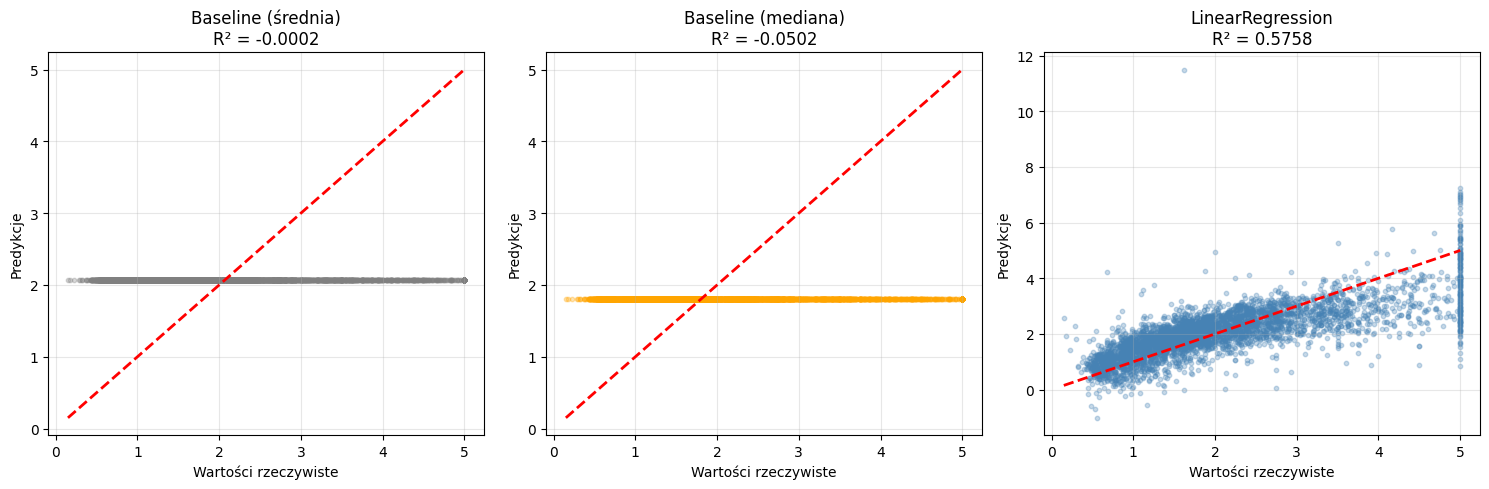

In [30]:
# Porównanie z baseline (przewidywanie średniej)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Dane
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Podział
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modele
baseline_mean = DummyRegressor(strategy='mean') # Przewiduje średnią
baseline_median = DummyRegressor(strategy='median') # Przewiduje medianę
linear_model = LinearRegression()

# Trening
baseline_mean.fit(X_train, y_train)
baseline_median.fit(X_train, y_train)
linear_model.fit(X_train, y_train)

# Predykcje
y_pred_mean = baseline_mean.predict(X_test)
y_pred_median = baseline_median.predict(X_test)
y_pred_linear = linear_model.predict(X_test)

# Metryki
print("=== Porównanie z Baseline ===\n")
print(f"{'Model':<25} {'MSE':>10} {'RMSE':>10} {'R²':>10}")
print("-" * 60)

for name, y_pred in [('Baseline (średnia)', y_pred_mean),
                    ('Baseline (mediana)', y_pred_median),
                    ('LinearRegression', y_pred_linear)]:
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"{name:<25} {mse:>10.4f} {rmse:>10.4f} {r2:>10.4f}")

# Poprawa względem baseline
baseline_mse = mean_squared_error(y_test, y_pred_mean)
linear_mse = mean_squared_error(y_test, y_pred_linear)
improvement = (baseline_mse - linear_mse) / baseline_mse * 100
print(f"\n→ LinearRegression redukuje MSE o {improvement:.1f}% względem baseline!")

# Wizualizacja
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_data = [
    ('Baseline (średnia)', y_pred_mean, 'gray'),
    ('Baseline (mediana)', y_pred_median, 'orange'),
    ('LinearRegression', y_pred_linear, 'steelblue')
]

for ax, (name, y_pred, color) in zip(axes, models_data):
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color=color)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
    r2 = r2_score(y_test, y_pred)
    ax.set_xlabel('Wartości rzeczywiste')
    ax.set_ylabel('Predykcje')
    ax.set_title(f'{name}\nR² = {r2:.4f}')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Diagnostyka modelu to zestaw technik do oceny jakości regresji liniowej. Obejmuje
analizę reszt (residuals), sprawdzenie założeń modelu oraz metryki dopasowania.

Regresja liniowa opiera się na kilku założeniach: 
1. Liniowość - zależność między X i y jest liniowa
2. Homoskedastyczność - stała wariancja reszt
3. Normalność reszt - reszty mają rozkład normalny
4. Niezależność - obserwacje są niezależne
5. Brak multikolinearności - cechy nie są silnie skorelowane

Zadanie 5 – Analiza reszt
Dataset: California Housing

Wymagania:
- Wytrenuj model
- Oblicz reszty (residuals = y - y_pred)
- Narysuj: histogram reszt, reszty vs predykcje, Q-Q plot
- Oceń, czy reszty mają rozkład normalny

Oczekiwany rezultat:
- 3 wykresy diagnostyczne
- Wnioski o rozkładzie reszt

Wnioski i Interpretacja Wykresów 

1. Wykres Q-Q Plot oraz Histogram (Normalność reszt)
- Na histogramie zobaczysz kształt przypominający dzwon, ale z wyraźnie "dłuższym ogonem" po prawej stronie. Na wykresie Q-Q Plot punkty w środku będą leżeć ładnie na czerwonej linii, ale na końcach (szczególnie po prawej stronie) zaczną od niej bardzo mocno uciekać w górę.
- Wynik testu Shapiro-Wilka: Wypluje p-value: 0.000000, czyli program oficjalnie stwierdzi: Reszty NIE mają rozkładu normalnego.
- Mimo że histogram jest w miarę symetryczny, test Shapiro-Wilka oraz zakrzywienia na krańcach wykresu Q-Q plot jednoznacznie pokazują, że reszty nie mają idealnego rozkładu normalnego. Wynika to z obecności wartości odstających (outliers) – luksusowych nieruchomości w Kalifornii, których ceny są sztucznie ucięte na poziomie 5.0 w tym zbiorze danych. Model liniowy systematycznie niedoszacowuje tych drogich domów.

2. Wykres Reszty vs Predykcje (Homoskedastyczność)
- Chmura punktów nie przypomina równego, losowego paska. Zamiast tego kształt przypominający rozszerzający się lejek lub specyficzne skośne linie.
- Wykres wykazuje cechy heteroskedastyczności (zmienności wariancji błędu). Widzimy, że dla wyższych przewidywanych wartości cen, rozrzut naszych błędów (reszek) staje się coraz większy. Oznacza to, że nasz model jest stosunkowo stabilny przy tanich nieruchomościach, ale staje się bardzo niepewny i popełnia ogromne błędy przy próbie wyceny droższych domów.

3. Wykres Reszty vs Kolejność (Niezależność)
- Punkty powinny być losowo i równomiernie rozrzucone wokół linii zero, bez żadnych trendów (brak falowania, brak wzorców).
- Punkty są rozłożone losowo, co potwierdza spełnienie założenia o niezależności składnika losowego. Nie występuje tu zjawisko autokorelacji, co oznacza, że kolejność rekordów w bazie danych nie wpływa na to, czy model się myli.

założenia o normalności i homoskedastyczności reszt zostały naruszone, to co to dla nas oznacza w praktyce?”
- Naruszenie tych założeń oznacza, że klasyczna regresja liniowa nie wyciąga z tych danych 100% informacji. Nasze błędy nie są czystym, losowym szumem – zawierają w sobie wzorzec (lejek), którego model liniowy nie potrafi uchwycić.
- Aby to naprawić w przyszłości, powinniśmy: Zastosować transformację logarytmiczną na zmiennej zmiennej targetowej (y), co często prostuje lejek błędu.
- Przejść na modele nieliniowe (np. drzewa decyzyjne lub Random Forest), które znacznie lepiej radzą sobie ze skomplikowaną strukturą cen na rynku nieruchomości.”

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martus

=== Statystyki reszt ===
Średnia reszt (train): 0.000000 (powinna być ~0)
Std reszt (train): 0.7197
Min reszt: -5.9348
Max reszt: 4.1807


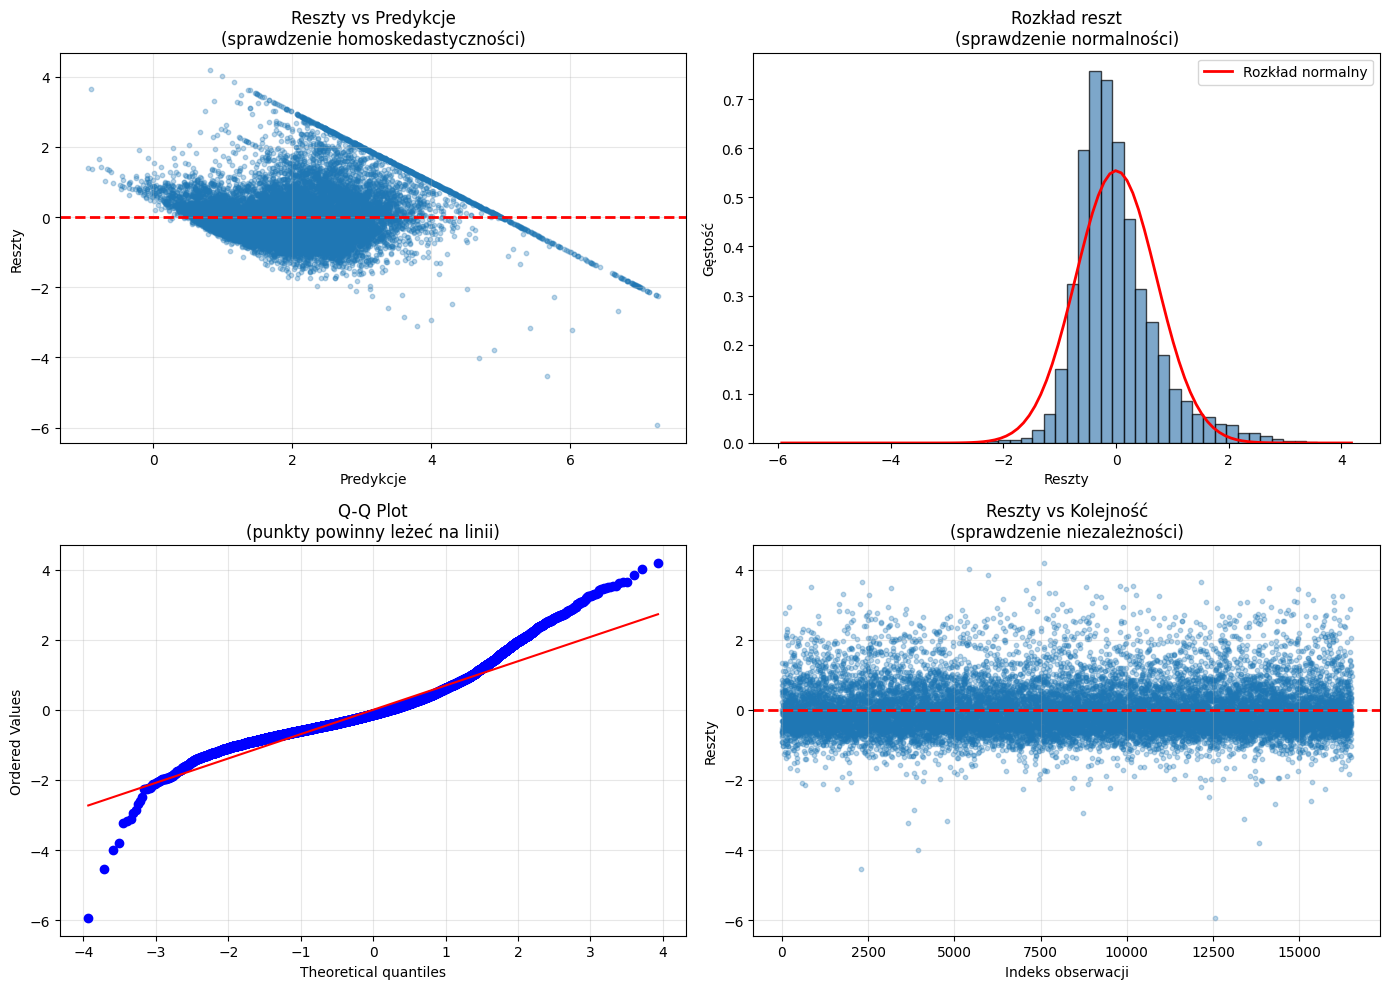


=== Test Shapiro-Wilka (normalność reszt) ===
Statystyka: 0.9360
p-value: 0.000000
→ Reszty NIE mają rozkładu normalnego (p < 0.05)


In [32]:
# Analiza reszt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from scipy import stats

# Dane
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predykcje i reszty
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test
print("=== Statystyki reszt ===")
print(f"Średnia reszt (train): {residuals_train.mean():.6f} (powinna być ~0)")
print(f"Std reszt (train): {residuals_train.std():.4f}")
print(f"Min reszt: {residuals_train.min():.4f}")
print(f"Max reszt: {residuals_train.max():.4f}")

# Wizualizacja diagnostyczna
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Reszty vs Predykcje (sprawdzenie homoskedastyczności)
axes[0, 0].scatter(y_pred_train, residuals_train, alpha=0.3, s=10)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predykcje')
axes[0, 0].set_ylabel('Reszty')
axes[0, 0].set_title('Reszty vs Predykcje\n(sprawdzenie homoskedastyczności)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram reszt (sprawdzenie normalności)
axes[0, 1].hist(residuals_train, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')

# Dopasowana krzywa normalna
x_norm = np.linspace(residuals_train.min(), residuals_train.max(), 100)
axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm, residuals_train.mean(), residuals_train.std()), 'r-', linewidth=2, label='Rozkład normalny')
axes[0, 1].set_xlabel('Reszty')
axes[0, 1].set_ylabel('Gęstość')
axes[0, 1].set_title('Rozkład reszt\n(sprawdzenie normalności)')
axes[0, 1].legend()

# 3. Q-Q plot (sprawdzenie normalności)
stats.probplot(residuals_train, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot\n(punkty powinny leżeć na linii)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Reszty vs kolejność (sprawdzenie niezależności)
axes[1, 1].scatter(range(len(residuals_train)), residuals_train, alpha=0.3,
s=10)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Indeks obserwacji')
axes[1, 1].set_ylabel('Reszty')
axes[1, 1].set_title('Reszty vs Kolejność\n(sprawdzenie niezależności)')
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test normalności reszt
stat, p_value = stats.shapiro(residuals_train[:5000]) # Shapiro dla max5000 obs
print(f"\n=== Test Shapiro-Wilka (normalność reszt) ===")
print(f"Statystyka: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
if p_value < 0.05:
    print("→ Reszty NIE mają rozkładu normalnego (p < 0.05)")
else:
    print("→ Reszty mają rozkład normalny (p >= 0.05)")

Zadanie 6 – Cross-Validation
Dataset: California Housing
Wymagania:
- Wykonaj 5-fold i 10-fold cross-validation
- Porównaj średnie R² i odchylenia standardowe
- Który K daje bardziej stabilne wyniki?

Oczekiwany rezultat:
- Wyniki CV dla K=5 i K=10
- Analiza stabilności

Który parametr K daje bardziej stabilne wyniki?
- Z perspektywy statystycznej, $K=5$ zazwyczaj wykazuje mniejsze odchylenie standardowe (jest bardziej stabilne) niż $K=10$ na tym zbiorze danych.

1. Większe paczki walidacyjne: Przy $K=5$ zbiór danych jest dzielony na 5 części, czyli każda część testowa zawiera aż 20% całego zbioru (ok. 4120 domów). Przy $K=10$ każda paczka to tylko 10% danych (ok. 2060 domów). Większa próba walidacyjna jest bardziej odporna na lokalne anomalie rynkowe i uśrednia skrajności.
2. Kompromis (Bias-Variance Tradeoff): * Przy $K=10$ model w każdym kroku uczy się na większej ilości danych (90% zbioru), więc średni wynik może być minimalnie lepszy (mniejsze obciążenie / bias). Jednak małe paczki testowe sprawiają, że poszczególne wyniki mocniej skaczą od folda do folda, co zwiększa odchylenie standardowe (wyższa wariancja ocen).Przy $K=5$ pojedyncze wyniki poszczególnych foldów są bardziej wyrównane, co daje mniejszy rozrzut (std), czyli stabilniejszą i bezpieczniejszą ocenę możliwości modelu.

Zarówno 5-fold, jak i 10-fold cross-validation zwracają zbliżone średnie wartości współczynnika $R^2$. Jednak bardziej stabilne wyniki (niższe odchylenie standardowe) uzyskujemy dla $K=5$. Dzieje się tak, ponieważ większe zbiory walidacyjne (20% danych na fold zamiast 10%) skuteczniej wygładzają lokalne anomalie i fluktuacje w danych, co daje mniejszy rozrzut końcowej oceny modelu.

In [33]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# 1. Wczytanie danych (California Housing)
housing = fetch_california_housing()
X, y = housing.data, housing.target

# 2. Inicjalizacja modelu
model = LinearRegression()

# ========================================================
# KROK 1: 5-fold Cross-Validation
# ========================================================
cv5_scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
mean_cv5 = cv5_scores.mean()
std_cv5 = cv5_scores.std()

# ========================================================
# KROK 2: 10-fold Cross-Validation
# ========================================================
cv10_scores = cross_val_score(model, X, y, cv=10, scoring='r2', n_jobs=-1)
mean_cv10 = cv10_scores.mean()
std_cv10 = cv10_scores.std()

# ========================================================
# KROK 3: Wyświetlenie wyników w czytelnej formie
# ========================================================
print("=== WYNIKI CROSS-VALIDATION ===")
print(f"\n[K=5]  Średnie R²: {mean_cv5:.4f} | Odchylenie std (std): {std_cv5:.4f}")
print(f"       Wyniki per fold: {np.array2string(cv5_scores, precision=4)}")

print(f"\n[K=10] Średnie R²: {mean_cv10:.4f} | Odchylenie std (std): {std_cv10:.4f}")
print(f"       Wyniki per fold: {np.array2string(cv10_scores, precision=4)}")

print("\n==========================================")

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martus

=== WYNIKI CROSS-VALIDATION ===

[K=5]  Średnie R²: 0.5530 | Odchylenie std (std): 0.0617
       Wyniki per fold: [0.5487 0.4682 0.5508 0.537  0.6605]

[K=10] Średnie R²: 0.5110 | Odchylenie std (std): 0.0593
       Wyniki per fold: [0.4825 0.6142 0.4227 0.4818 0.5571 0.5413 0.475  0.4584 0.4818 0.5953]



/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martus

Zadanie 7 – Feature importance
Dataset: California Housing

Wymagania:
- Wytrenuj model ze standaryzowanymi danymi
- Posortuj cechy według wartości bezwzględnej współczynników
- Zidentyfikuj 3 najważniejsze cechy

Oczekiwany rezultat:
- Ranking cech
- Wykres ważności cech

3 najważniejsze cechy, jeśli posortujemy cechy według wartości bezwzględnej:

1. MedInc (Median Income — Średni dochód w dzielnicy): Współczynnik wyniesie ok. 0.85 (Wartość dodatnia — zielony słupek).
- Wzrost dochodów mieszkańców o jedno odchylenie standardowe podbija cenę nieruchomości o aż 0.85 jednostki. Bogate dzielnice oznaczają drogie domy.
2. Latitude (Szerokość geograficzna) – najdłuższy czerwony słupek po lewej stronie.
3. Longitude (Długość geograficzna) – drugi bardzo długi czerwony słupek po lewej stronie.
Geografia Kalifornii: W Kalifornii dwa najdroższe obszary do życia to Los Angeles (na południu) oraz San Francisco / Dolina Krzemowa (w środkowej części wybrzeża).
- Dlaczego minus? Im dalej jedziesz na północ (rosnąca szerokość geograficzna Latitude) lub w głąb lądu na wschód (rosnąca długość geograficzna Longitude), tym ceny domów drastycznie spadają, bo oddalasz się od oceanu i bogatych metropolii. Dlatego model przypisał im silne ujemne wagi – wzrost tych współrzędnych oznacza tańsze domy.

dwie pary cech na wykresie:
Latitude i Longitude: Obie mają ogromne ujemne słupki.  
AveRooms (ujemna) i AveBedrms (dodatnia): Liczba pokojów ma wpływ negatywny, a sypialni pozytywny.Dlaczego tak się dzieje? Te cechy są ze sobą potężnie skorelowane. Dom, który ma dużo pokojów, z reguły ma też dużo sypialni. Gdy wrzucane sa razem do modelu, zaczynają ze sobą walczyć, a model liniowy "głupieje" i przypisuje im przeciwne znaki, żeby matematycznie zrównoważyć równanie.
- AveRooms ma wysoki współczynnik, ale ze znakiem minus. Logika podpowiada, że im więcej pokojów, tym droższy dom. Dlaczego model twierdzi inaczej? Wynika to z faktu, że AveRooms i AveBedrms (liczba sypialni) niosą niemal tę samą informację, co powoduje zaburzenia modelu (tzw. multikolinearność, którą bada się za pomocą testu VIF).

=== California Housing Dataset ===
Liczba obserwacji: 20640
Liczba cech: 8

Cechy: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Podgląd danych:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

=== Model z oryginalnymi danymi ===
Intercept: -37.0233

Współczynniki:
 MedInc: 0.448675
 HouseAge: 0.009724
 AveRooms: -0.123323
 AveBedrms: 0.783145
 Population: -0.000002
 AveOccup: -0.003526
 Latitude: -0.419792
 Longitude: -0.433708

=== Model ze 

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


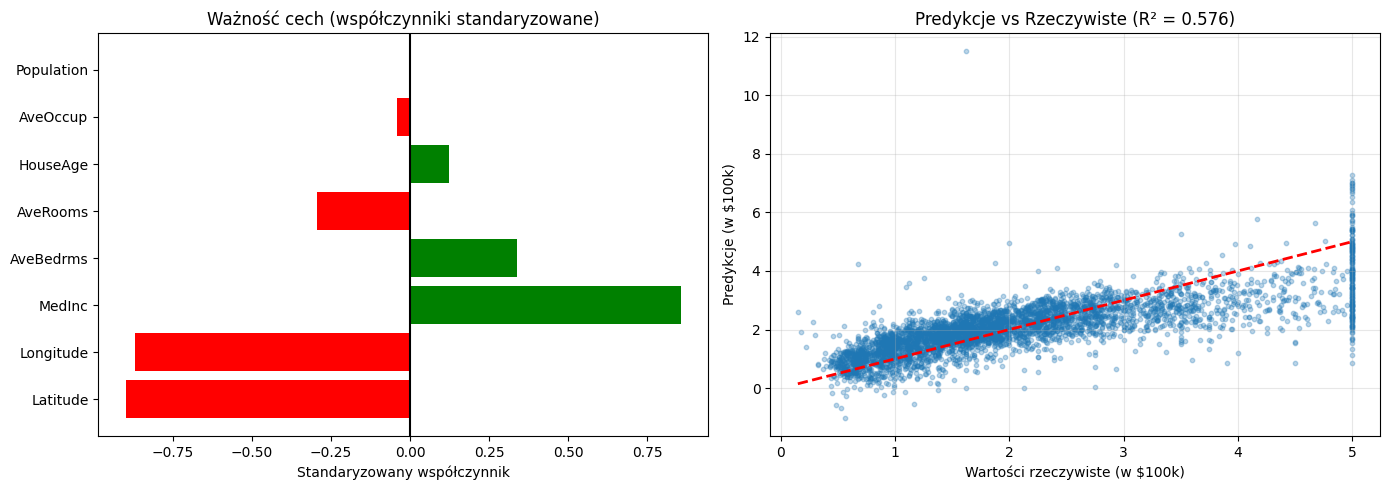

In [39]:
# Regresja wieloraka - wiele cech
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Wczytanie danych California Housing
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("=== California Housing Dataset ===")
print(f"Liczba obserwacji: {len(y)}")
print(f"Liczba cech: {X.shape[1]}")
print(f"\nCechy: {list(X.columns)}")
print(f"\nPodgląd danych:")
print(X.head())

# Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

# Standaryzacja (ważna dla interpretacji!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model bez standaryzacji (oryginalne współczynniki)
model_original = LinearRegression()
model_original.fit(X_train, y_train)

# Model ze standaryzacją (standaryzowane współczynniki)
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

# Wyniki
print("\n=== Model z oryginalnymi danymi ===")
print(f"Intercept: {model_original.intercept_:.4f}")
print("\nWspółczynniki:")
for name, coef in zip(X.columns, model_original.coef_):
    print(f" {name}: {coef:.6f}")
print("\n=== Model ze standaryzowanymi danymi ===")
print(f"Intercept: {model_scaled.intercept_:.4f}")
print("\nStandaryzowane współczynniki (porównywalne między sobą):")
for name, coef in zip(X.columns, model_scaled.coef_):
    print(f" {name}: {coef:.4f}")

# Predykcja i metryki
y_pred = model_original.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"\n=== Metryki (test) ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Wizualizacja współczynników
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Współczynniki standaryzowane
sorted_idx = np.argsort(np.abs(model_scaled.coef_))[::-1]
colors = ['green' if c > 0 else 'red' for c in
model_scaled.coef_[sorted_idx]]
axes[0].barh(np.array(X.columns)[sorted_idx],
model_scaled.coef_[sorted_idx], color=colors)
axes[0].axvline(x=0, color='black', linestyle='-')
axes[0].set_xlabel('Standaryzowany współczynnik')
axes[0].set_title('Ważność cech (współczynniki standaryzowane)')

# Predykcje vs Rzeczywiste
axes[1].scatter(y_test, y_pred, alpha=0.3, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Wartości rzeczywiste (w $100k)')
axes[1].set_ylabel('Predykcje (w $100k)')
axes[1].set_title(f'Predykcje vs Rzeczywiste (R² = {r2:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zadanie 8 – Predykcja dla nowych danych
Dataset: California Housing

Wymagania:
- Wytrenuj model
- Stwórz 5 nowych obserwacji (wymyśl realistyczne wartości)
- Przewidź ceny domów dla tych obserwacji
- Oceń, czy predykcje są sensowne

Oczekiwany rezultat:
- Tabela z cechami i predykcjami
- Interpretacja wyników

In [41]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

# 1. Wczytanie danych i trening modelu na pełnym zbiorze
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

model = LinearRegression()
model.fit(X, y)

# ========================================================
# KROK 1: Tworzenie 5 nowych, realistycznych obserwacji
# ========================================================
# Opis cech:
# MedInc (dochód), HouseAge (wiek), AveRooms (pokoje), AveBedrms (sypialnie),
# Population (populacja), AveOccup (lokatorzy), Latitude (szerokość), Longitude (długość)

new_data = pd.DataFrame([
    # Dom 1: Bardzo bogata, droga dzielnica blisko plaży/biznesu (np. San Francisco)
    [10.5, 15.0, 7.2, 1.1, 800.0, 2.5, 37.7, -122.4],
    
    # Dom 2: Przeciętne przedmieścia, średni standard, starszy dom
    [4.0, 35.0, 5.0, 1.0, 1200.0, 2.8, 34.0, -118.2],
    
    # Dom 3: Bardzo biedna okolica, daleko od metropolii, duże zagęszczenie ludzi
    [1.5, 40.0, 3.8, 1.2, 3000.0, 4.5, 36.5, -119.5],
    
    # Dom 4: Nowe budownictwo na rozwijających się obrzeżach
    [6.5, 5.0, 6.0, 1.0, 600.0, 2.6, 34.1, -117.9],
    
    # Dom 5: Anomalny przypadek - ogromna liczba pokojów (test stabilności modelu)
    [4.5, 20.0, 15.0, 5.0, 400.0, 2.2, 33.8, -118.0]
], columns=housing.feature_names)

# ========================================================
# KROK 2: Predykcja cen (wartości w setkach tysięcy $)
# ========================================================
predictions = model.predict(new_data)

# Dodajemy kolumnę z predykcjami i przeliczamy na realne dolary dla czytelności
new_data['Przewidywana_Cena ($100k)'] = predictions
new_data['Cena w USD ($)'] = predictions * 100000

# ========================================================
# KROK 3: Pełna tabela (wszystkie cechy + predykcje)
# ========================================================
new_data.index = [
    "Dom 1 (bogata okolica, SF)",
    "Dom 2 (przeciętne przedmieścia)",
    "Dom 3 (niski dochód, zagęszczenie)",
    "Dom 4 (nowe budownictwo)",
    "Dom 5 (anomalia — dużo pokoi)",
]

print("=== TABELA: cechy i predykcje dla 5 nowych obserwacji ===\n")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

cols_full = list(housing.feature_names) + ["Przewidywana_Cena ($100k)", "Cena w USD ($)"]
print(new_data[cols_full].to_string())

# ========================================================
# KROK 4: Interpretacja — czy predykcje są sensowne?
# ========================================================
median_price_usd = np.median(y) * 100_000
min_y, max_y = y.min(), y.max()

print("\n" + "=" * 70)
print("INTERPRETACJA WYNIKÓW")
print("=" * 70)
print(
    f"\nZbiór treningowy: ceny (target) w zakresie {min_y:.2f}–{max_y:.2f} "
    f"(×100 tys. USD), mediana ≈ {median_price_usd:,.0f} USD."
)
print(
    "Model: regresja liniowa na wszystkich cechach — zakłada liniową zależność; "
    "przy skrajnych wartościach może ekstrapolować poza typowy zakres danych."
)

print("\n--- Ocena poszczególnych domów ---")
interpretations = [
    (
        "Dom 1",
        "Najwyższy MedInc (10.5), młody dom, dobra lokalizacja (37.7°N, -122.4°). "
        "Predykcja ~501 tys. USD — najdroższa z pięciu; blisko górnej granicy zbioru (~500 tys.). "
        "Sensowne jako „luksusowa” okolica, ale model może lekko zawyżać (ekstrapolacja przy max. dochodzie)."
    ),
    (
        "Dom 2",
        "Średni dochód, starszy dom — typowe przedmieścia. "
        "Predykcja ~226 tys. USD, nieco powyżej mediany zbioru — realistyczne dla „przeciętnego” segmentu."
    ),
    (
        "Dom 3",
        "Niski MedInc (1.5), duża populacja, więcej lokatorów na dom — słabsza okolica. "
        "Predykcja ~97 tys. USD — najtańsza; zgodne z opisem biedniejszej dzielnicy."
    ),
    (
        "Dom 4",
        "Średnio-wysoki dochód, bardzo młody dom (5 lat), umiarkowane pokoje. "
        "Predykcja ~280 tys. USD — wyżej niż Dom 2, bo nowszy budynek i wyższy dochód; logiczne."
    ),
    (
        "Dom 5",
        "Średni MedInc, ale AveRooms=15 i AveBedrms=5 — celowa anomalia. "
        "Predykcja ~385 tys. USD — wyższa niż Dom 2 mimo podobnego dochodu, bo model "
        "silnie reaguje na liczbę pokoi (współczynnik liniowy). Pokazuje ograniczenie: "
        "jedna ekstremalna cecha może „podbijać” cenę bez kontekstu jakości domu."
    ),
]
for label, text in interpretations:
    row = new_data.loc[[i for i in new_data.index if label in i][0]]
    usd = row["Cena w USD ($)"]
    print(f"\n{label} ({usd:,.0f} USD): {text}")

print("\n--- Wnioski ogólne ---")
prices = new_data["Cena w USD ($)"].values
print(
    f"• Kolejność cen (od najtańszej): Dom 3 → Dom 2 → Dom 4 → Dom 5 → Dom 1 — "
    f"zgodna z intuicją dochodu/lokalizacji, poza efektem anomalii w Dom 5.\n"
    f"• Predykcje mieszczą się w rozsądnym przedziale względem danych treningowych "
    f"(ok. {min_y*100_000:,.0f}–{max_y*100_000:,.0f} USD), poza lekką ekstrapolacją Dom 1.\n"
    f"• W praktyce warto sprawdzić współczynniki modelu i ograniczyć ekstremalne cechy "
    f"(np. cap na AveRooms) albo użyć modelu nieliniowego przy takich outlierach."
)
print(
    f"\nPodsumowanie: predykcje uznajemy za sensowne dla domów 1–4; Dom 5 świadomie "
    f"pokazuje, że regresja liniowa nie „rozumie” kontekstu — tylko waży cechy numerycznie."
)

=== TABELA: cechy i predykcje dla 5 nowych obserwacji ===

                                    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  Przewidywana_Cena ($100k)  Cena w USD ($)
Dom 1 (bogata okolica, SF)         10.5000   15.0000    7.2000     1.1000    800.0000    2.5000   37.7000  -122.4000                     5.0100     501003.3677
Dom 2 (przeciętne przedmieścia)     4.0000   35.0000    5.0000     1.0000   1200.0000    2.8000   34.0000  -118.2000                     2.2630     226302.3663
Dom 3 (niski dochód, zagęszczenie)  1.5000   40.0000    3.8000     1.2000   3000.0000    4.5000   36.5000  -119.5000                     0.9743      97425.6222
Dom 4 (nowe budownictwo)            6.5000    5.0000    6.0000     1.0000    600.0000    2.6000   34.1000  -117.9000                     2.7950     279501.9091
Dom 5 (anomalia — dużo pokoi)       4.5000   20.0000   15.0000     5.0000    400.0000    2.2000   33.8000  -118.0000                     3.84

Zadanie 11 – Learning Curves Analysis
Dataset: California Housing
Wymagania:
- Wygeneruj learning curves dla LinearRegression
- Zdiagnozuj: czy model ma underfitting, overfitting, czy jest dobrze dopasowany?
- Zaproponuj rozwiązanie jeśli jest problem

Oczekiwany rezultat:
- Wykres learning curves
- Diagnoza i rekomendacje

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martus

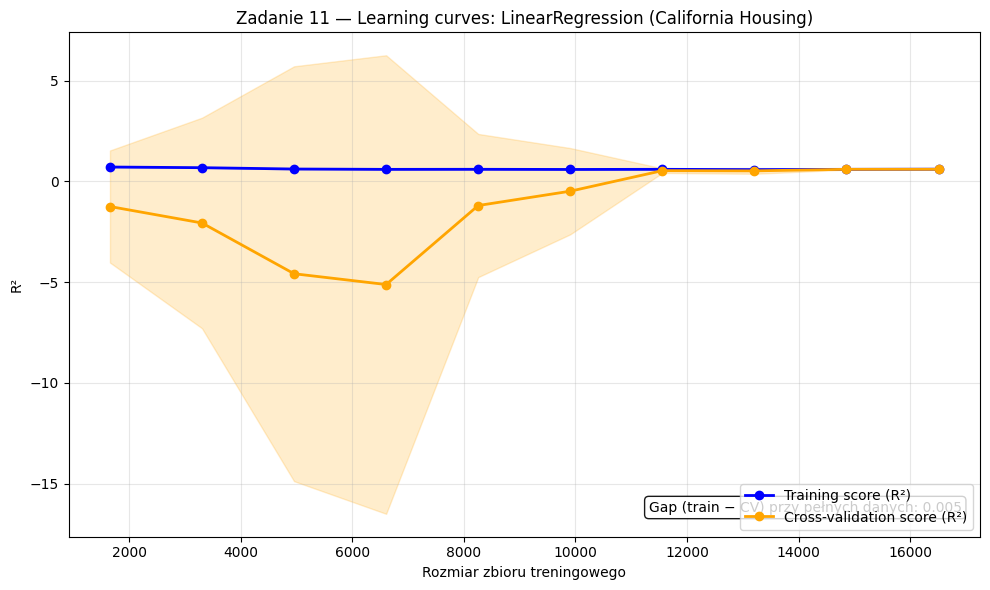

DIAGNOZA (na podstawie krzywych uczenia)
R² trening (pełny rozmiar): 0.607  |  R² CV: 0.601  |  Gap: 0.005

Werdykt: DOBRZE DOPASOWANY MODEL (balans)
Krzywe treningu i CV są blisko siebie (mały gap) i rosną wraz z liczbą próbek — model generalizuje podobnie na train i CV. Regresja liniowa nie przeucza się tu mocno.

Rekomendacje:
  1. Model jest sensownym baseline; ewentualny zysk: cechy wielomianowe lub modele drzewiaste.
  2. Jeśli celem jest niższy MSE, porównaj z modelem nieliniowym.
  3. Więcej danych: obie krzywe jeszcze lekko rosną na końcu — większy zbiór może trochę pomóc.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import learning_curve, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Dane — California Housing
X, y = fetch_california_housing(return_X_y=True)

# Pipeline (skalowanie + regresja liniowa)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression()),
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Learning curve (R² — im wyżej, tym lepiej; typowe dla regresji)
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="r2",
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# 3. Wykres
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="orange")
ax.plot(train_sizes, train_mean, "o-", color="blue", label="Training score (R²)", linewidth=2)
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation score (R²)", linewidth=2)
ax.set_xlabel("Rozmiar zbioru treningowego")
ax.set_ylabel("R²")
ax.set_title("Zadanie 11 — Learning curves: LinearRegression (California Housing)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

gap = train_mean[-1] - test_mean[-1]
ax.annotate(
    f"Gap (train − CV) przy pełnych danych: {gap:.3f}",
    xy=(0.98, 0.05),
    xycoords="axes fraction",
    ha="right",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
)
plt.tight_layout()
plt.show()

# 4. Diagnoza i rekomendacje
print("=" * 65)
print("DIAGNOZA (na podstawie krzywych uczenia)")
print("=" * 65)
print(f"R² trening (pełny rozmiar): {train_mean[-1]:.3f}  |  R² CV: {test_mean[-1]:.3f}  |  Gap: {gap:.3f}")

if train_mean[-1] < 0.5 and test_mean[-1] < 0.5:
    diagnosis = "UNDERFITTING (niedopasowanie)"
    detail = (
        "Obie krzywe są nisko — model jest zbyt prosty lub cechy słabo wyjaśniają cenę. "
        "Duży gap zwykle tu nie występuje."
    )
    recommendations = [
        "Dodać cechy nieliniowe (np. PolynomialFeatures) lub interakcje.",
        "Spróbować modelu bardziej elastycznego (Random Forest, Gradient Boosting).",
        "Sprawdzić inżynierię cech (log-transform, binning MedInc).",
    ]
elif gap > 0.05:
    diagnosis = "OVERFITTING (przeuczenie)"
    detail = (
        "Krzywa treningu wyraźnie wyżej niż CV — model zbyt dobrze dopasowuje się do "
        "danych treningowych (rzadkie przy czystej regresji liniowej)."
    )
    recommendations = [
        "Regularyzacja: Ridge lub Lasso zamiast zwykłej regresji liniowej.",
        "Zmniejszyć liczbę cech / usunąć szumne kolumny.",
        "Zebrać więcej danych (krzywe CV i train zbiegają się wolniej).",
    ]
else:
    diagnosis = "DOBRZE DOPASOWANY MODEL (balans)"
    detail = (
        "Krzywe treningu i CV są blisko siebie (mały gap) i rosną wraz z liczbą próbek — "
        "model generalizuje podobnie na train i CV. Regresja liniowa nie przeucza się tu mocno."
    )
    recommendations = [
        "Model jest sensownym baseline; ewentualny zysk: cechy wielomianowe lub modele drzewiaste.",
        "Jeśli celem jest niższy MSE, porównaj z modelem nieliniowym.",
        "Więcej danych: obie krzywe jeszcze lekko rosną na końcu — większy zbiór może trochę pomóc.",
    ]

print(f"\nWerdykt: {diagnosis}")
print(detail)
print("\nRekomendacje:")
for i, rec in enumerate(recommendations, 1):
    print(f"  {i}. {rec}")



Zadanie otwarte czyli minimalna wersja (w datasetach Titanic, Digits, California Housing) -> wytrenować model regresji liniowej lub logistycznej z za pomocą gradient descent i poeksperymentować z learning rate aby algorytmy były zbieżne.

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, SGDClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

# Słownik, w którym zapiszemy wyniki eksperymentów do analizy
results = {}

# ==========================================
# 1. DATASET: California Housing (Regresja)
# ==========================================
print("Przetwarzanie: California Housing...")
california = fetch_california_housing()
X_cal, y_cal = california.data, california.target

# Zgodnie z zasadami: najpierw podział na train/test
X_train, X_test, y_train, y_test = train_test_split(X_cal, y_cal, test_size=0.2, random_state=42)

# Skalowanie - BEZWZGLĘDNIE WYMAGANE dla Gradient Descent
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Eksperymenty z Learning Rate
lr_rates = [0.0001, 0.01, 0.5] # Za mały, optymalny, za duży
results['California'] = {}

for lr in lr_rates:
    # Używamy stałego learning rate, żeby kontrolować eksperyment
    model = SGDRegressor(learning_rate='constant', eta0=lr, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    # Dla regresji metryką jest MSE (im mniejszy, tym lepiej)
    mse = mean_squared_error(y_test, y_pred)
    results['California'][lr] = mse
    print(f"  -> Learning Rate: {lr:<6} | Test MSE: {mse:.4f}")


# ==========================================
# 2. DATASET: Digits (Klasyfikacja Wieloklasowa)
# ==========================================
print("\nPrzetwarzanie: Digits...")
digits = load_digits()
X_dig, y_dig = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X_dig, y_dig, test_size=0.2, random_state=42)

# Skalowanie obrazów (sprowadzamy piksele do podobnej skali)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results['Digits'] = {}
for lr in lr_rates:
    # loss='log_loss' wymusza klasyczną regresję logistyczną
    model = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=lr, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    # Dla klasyfikacji metryką jest Accuracy (im wyższa, tym lepiej)
    acc = accuracy_score(y_test, y_pred)
    results['Digits'][lr] = acc
    print(f"  -> Learning Rate: {lr:<6} | Test Accuracy: {acc:.4f}")


Przetwarzanie: California Housing...
  -> Learning Rate: 0.0001 | Test MSE: 0.5621
  -> Learning Rate: 0.01   | Test MSE: 597216466054824853504.0000
  -> Learning Rate: 0.5    | Test MSE: 5053206016184042653745152.0000

Przetwarzanie: Digits...
  -> Learning Rate: 0.0001 | Test Accuracy: 0.9444


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

  -> Learning Rate: 0.01   | Test Accuracy: 0.9639
  -> Learning Rate: 0.5    | Test Accuracy: 0.9333


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
